# Rope Flow — Data-Driven 3D Trajectory Reconstruction
**Data-Driven Modeling in Science and Engineering · AUB Spring 2026**

---

## Overview

This notebook implements the full trajectory reconstruction pipeline for IMU-based rope flow using **both hands simultaneously**. Device 0 (right hand) and Device 1 (left hand) are the two extremes of the rope — reconstructing both gives the complete rope flow geometry.

| Stage | Method | Course lecture |
|-------|--------|----------------|
| **2A** | SINDy — discover governing dynamics from data | Lectures 8–9 |
| **2B** | PINN — inverse problem: reconstruct trajectory under physics constraints | Lecture 13 |
| **2C** | DMD + Autoencoder — extract modes for pattern recognition | Lectures 15–16 |

**Input** (Stage 1 output — Madgwick filter): `timestamp_ms`, `qw/qx/qy/qz`, `ax_w/ay_w/az_w` at 50 Hz.

---
## 0. Setup & Data Loading

In [48]:
# !pip install pysindy torch matplotlib scipy scikit-learn

In [49]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal, integrate
from scipy.linalg import svd
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import pysindy as ps
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
C = {
    'dev0':  '#5DCAA5',
    'dev1':  '#7F77DD',
    'naive': '#E24B4A',
    'pinn':  '#EF9F27',
    'gray':  '#888780',
}
print('pysindy:', ps.__version__)
print('torch  :', torch.__version__)

pysindy: 2.1.0
torch  : 2.10.0+cpu


In [50]:
# ── Load both devices ────────────────────────────────────────────
data_dir  = '../../data/processed'
csv_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))

d0 = pd.read_csv([f for f in csv_files if 'device0' in f][0])
d1 = pd.read_csv([f for f in csv_files if 'device1' in f][0])

print(f'Device 0 (right): {len(d0)} samples | {d0.timestamp_ms.iloc[-1]/1000:.1f}s')
print(f'Device 1 (left):  {len(d1)} samples | {d1.timestamp_ms.iloc[-1]/1000:.1f}s')
d0.head(3)

Device 0 (right): 2254 samples | 45.1s
Device 1 (left):  2256 samples | 45.1s


,timestamp_ms,qw,qx,qy,qz,ax_w,ay_w,az_w
0,0.000000,0.999912,-0.001946,0.010487,-0.007944,-5.003219,-5.585140,1.644119
1,20.000444,0.999672,-0.006473,0.019537,-0.015250,-4.937916,-5.303028,1.822499
2,40.000888,0.999296,-0.013341,0.027065,-0.022309,-4.742344,-5.201602,1.734194


In [51]:
def preprocess(df):
    """
    Extract signals and derive angular velocity from quaternion.
    Returns t (N,), Q (N,4), A (N,3), omega (N,3).
    """
    t = df['timestamp_ms'].values / 1000.0
    Q = df[['qw','qx','qy','qz']].values
    A = df[['ax_w','ay_w','az_w']].values
    dQ = np.gradient(Q, t, axis=0)
    qw,qx,qy,qz = Q[:,0],Q[:,1],Q[:,2],Q[:,3]
    omega = np.column_stack([
        2*(-qx*dQ[:,0]+qw*dQ[:,1]+qz*dQ[:,2]-qy*dQ[:,3]),
        2*(-qy*dQ[:,0]-qz*dQ[:,1]+qw*dQ[:,2]+qx*dQ[:,3]),
        2*(-qz*dQ[:,0]+qy*dQ[:,1]-qx*dQ[:,2]+qw*dQ[:,3]),
    ])
    return t, Q, A, omega

t0, Q0, A0, om0 = preprocess(d0)
t1, Q1, A1, om1 = preprocess(d1)
state_names = ['ax','ay','az','wx','wy','wz']
print('Shapes A0:', A0.shape, ' A1:', A1.shape)

Shapes A0: (2254, 3)  A1: (2256, 3)


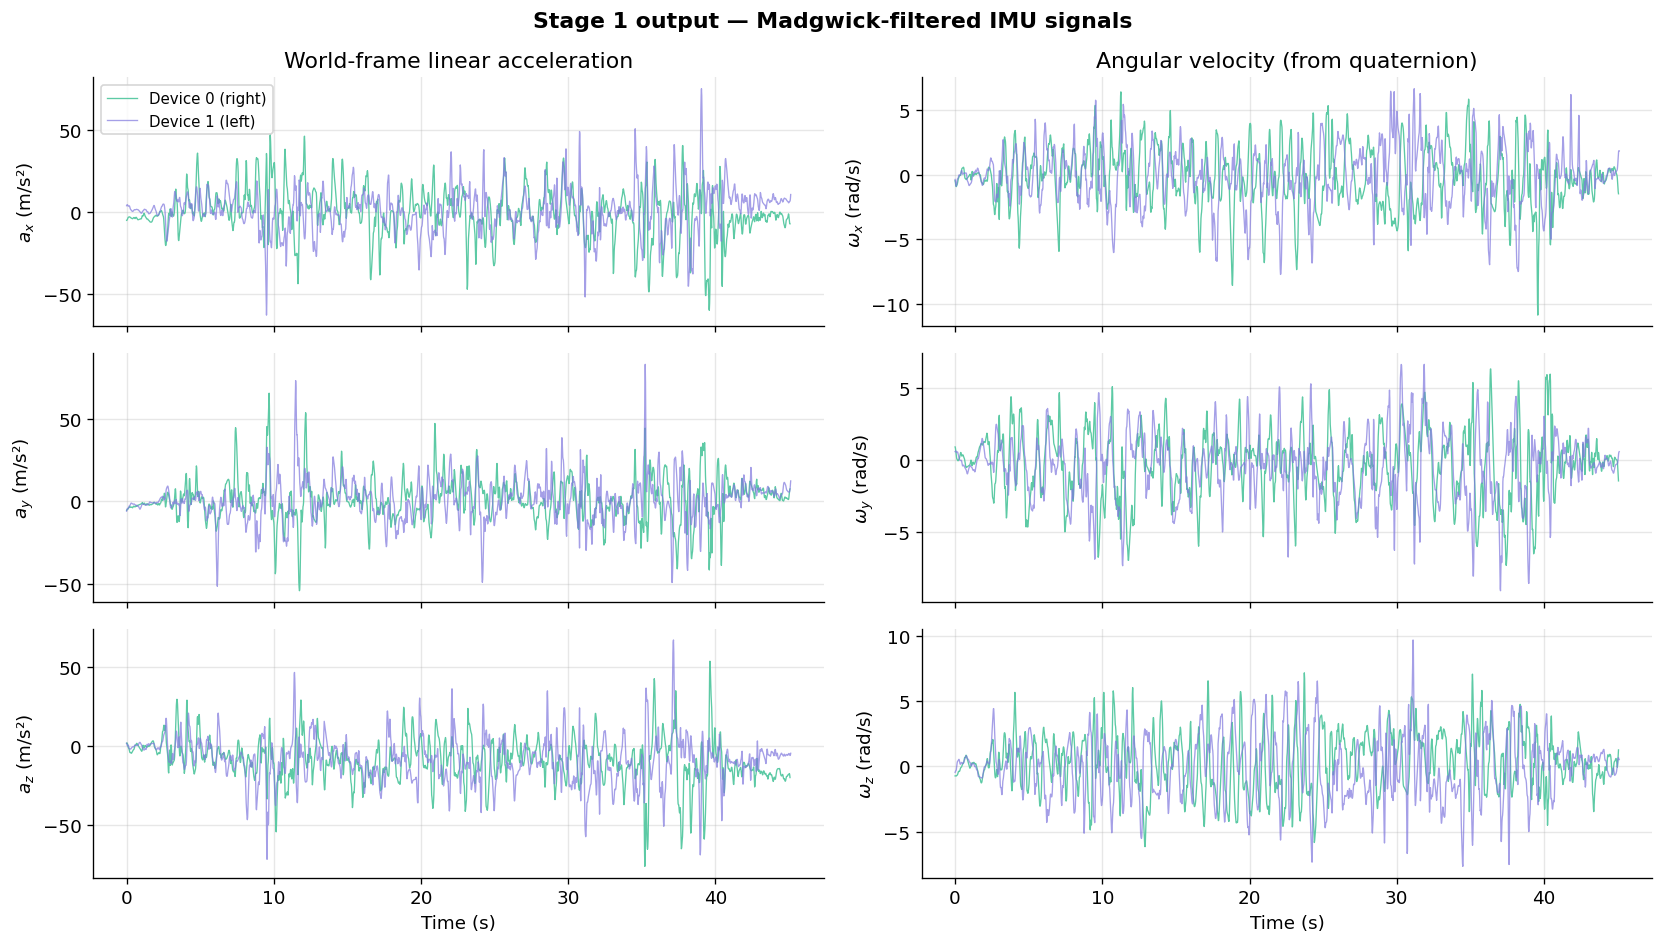

In [52]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
a_lbls = ['$a_x$ (m/s²)','$a_y$ (m/s²)','$a_z$ (m/s²)']
o_lbls = ['$\\omega_x$ (rad/s)','$\\omega_y$ (rad/s)','$\\omega_z$ (rad/s)']
for i in range(3):
    axes[i,0].plot(t0, A0[:,i],  color=C['dev0'], lw=0.8, label='Device 0 (right)')
    axes[i,0].plot(t1, A1[:,i],  color=C['dev1'], lw=0.8, alpha=0.7, label='Device 1 (left)')
    axes[i,0].set_ylabel(a_lbls[i])
    axes[i,1].plot(t0, om0[:,i], color=C['dev0'], lw=0.8)
    axes[i,1].plot(t1, om1[:,i], color=C['dev1'], lw=0.8, alpha=0.7)
    axes[i,1].set_ylabel(o_lbls[i])
axes[0,0].set_title('World-frame linear acceleration')
axes[0,1].set_title('Angular velocity (from quaternion)')
axes[0,0].legend(fontsize=9)
for ax in axes[-1]: ax.set_xlabel('Time (s)')
plt.suptitle('Stage 1 output — Madgwick-filtered IMU signals', fontweight='bold')
plt.tight_layout()
plt.show()

### 0.1 — Cycle Segmentation (both devices)

Boundaries are detected independently per device from peaks in $\|\boldsymbol{\omega}(t)\|$, then aligned to the same number of cycles.

In [53]:
def detect_cycles(t, omega, min_period=0.5, prominence=1.5, label=''):
    mag    = np.linalg.norm(omega, axis=1)
    smooth = signal.savgol_filter(mag, window_length=11, polyorder=3)
    sr     = 1.0 / np.median(np.diff(t))
    peaks, _ = signal.find_peaks(smooth, distance=int(min_period*sr), prominence=prominence)
    bounds   = [0]+[(peaks[i]+peaks[i+1])//2 for i in range(len(peaks)-1)]+[len(t)-1]
    cycles   = [(bounds[i], bounds[i+1]) for i in range(len(bounds)-1)]
    durs     = [t[e]-t[s] for s,e in cycles]
    print(f'{label}: {len(peaks)} peaks -> {len(cycles)} cycles | '
          f'mean T={np.mean(durs):.2f}s +/- {np.std(durs):.2f}s')
    return cycles, smooth, peaks

cycles0, sm0, pks0 = detect_cycles(t0, om0, label='Device 0')
cycles1, sm1, pks1 = detect_cycles(t1, om1, label='Device 1')
# ── Pair cycles by maximum time overlap across both devices ──────
def pair_cycles_by_overlap(t0, cycles0, t1, cycles1):
    """
    Greedily match each cycle from the shorter list to the cycle
    on the other device whose time window overlaps it the most.
    Returns two lists of equal length containing matched (s,e) pairs.
    """
    def overlap(s0, e0, s1, e1):
        lo = max(t0[s0], t1[s1])
        hi = min(t0[e0], t1[e1])
        return max(0.0, hi - lo)

    paired0, paired1 = [], []
    used = set()

    for c0 in cycles0:
        best_idx, best_ov = -1, -1.0
        for i, c1 in enumerate(cycles1):
            if i in used:
                continue
            ov = overlap(c0[0], c0[1], c1[0], c1[1])
            if ov > best_ov:
                best_ov, best_idx = ov, i
        if best_idx >= 0 and best_ov > 0:
            paired0.append(c0)
            paired1.append(cycles1[best_idx])
            used.add(best_idx)

    return paired0, paired1

cycles0, cycles1 = pair_cycles_by_overlap(t0, cycles0, t1, cycles1)
n_cycles = len(cycles0)
print(f'Paired cycles: {n_cycles}  '
      f'(D0 had {len(detect_cycles(t0, om0)[0])}, '
      f'D1 had {len(detect_cycles(t1, om1)[0])} before pairing)')

Device 0: 49 peaks -> 49 cycles | mean T=0.92s +/- 0.41s
Device 1: 46 peaks -> 46 cycles | mean T=0.98s +/- 0.41s
: 49 peaks -> 49 cycles | mean T=0.92s +/- 0.41s
: 46 peaks -> 46 cycles | mean T=0.98s +/- 0.41s
Paired cycles: 42  (D0 had 49, D1 had 46 before pairing)


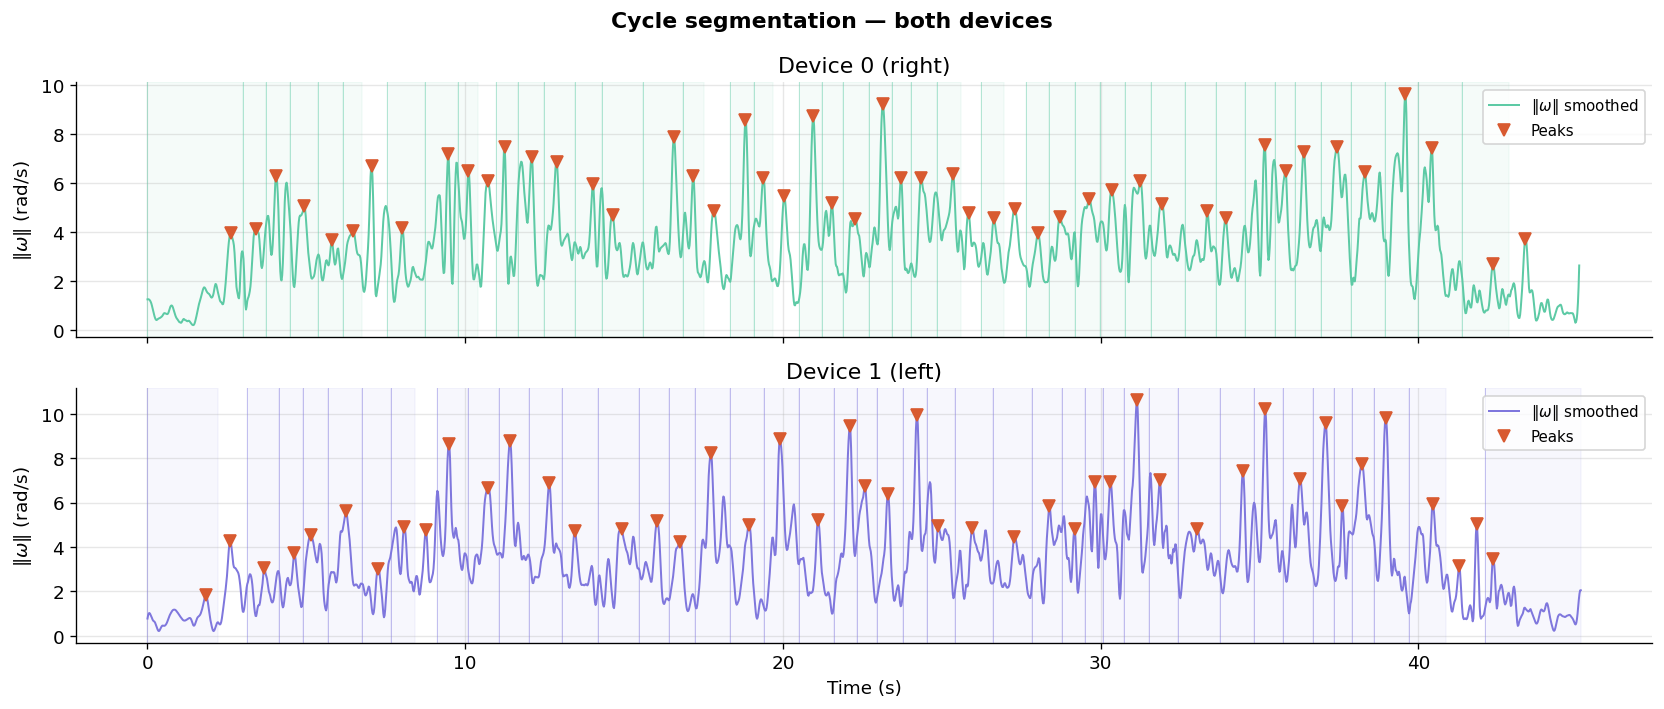

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, t, sm, pks, cycs, label, col in [
    (axes[0], t0, sm0, pks0, cycles0, 'Device 0 (right)', C['dev0']),
    (axes[1], t1, sm1, pks1, cycles1, 'Device 1 (left)',  C['dev1']),
]:
    ax.plot(t, sm, color=col, lw=1.2, label='$\\|\\omega\\|$ smoothed')
    ax.plot(t[pks], sm[pks], 'v', color='#D85A30', ms=7, label='Peaks')
    for s,e in cycs:
        ax.axvspan(t[s], t[e], alpha=0.06, color=col)
        ax.axvline(t[s], color=col, lw=0.6, alpha=0.4)
    ax.set_ylabel('$\\|\\omega\\|$ (rad/s)')
    ax.set_title(label)
    ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Cycle segmentation — both devices', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2A — SINDy: Sparse Identification of Nonlinear Dynamics

**State vector** (signal space — no integration needed):
$$\mathbf{x}(t) = [a_x, a_y, a_z, \omega_x, \omega_y, \omega_z]^\top$$

**Library**: Polynomial (degree 2) + Fourier — Fourier terms are essential to sparsely represent the periodic couplings in rope flow.

**Cross-device test**: Fit on Device 0, score on Device 1. If R² transfers, the equations reflect true rope-flow dynamics rather than device-specific artefacts.

In [55]:
X0 = np.hstack([A0, om0])   # (N, 6)
X1 = np.hstack([A1, om1])
dt_s = float(np.median(np.diff(t0)))
print(f'State matrix: {X0.shape} | dt={dt_s*1000:.1f}ms')

State matrix: (2254, 6) | dt=20.0ms


In [56]:
model = ps.SINDy(
    feature_library=ps.GeneralizedLibrary([
        ps.PolynomialLibrary(degree=2, include_bias=True),
        ps.FourierLibrary(n_frequencies=1)
    ]),
    optimizer=ps.STLSQ(threshold=0.1, alpha=0.05, max_iter=20),
    differentiation_method=ps.SmoothedFiniteDifference(smoother_kws={'window_length': 11}),
)
model.fit(X0, t=t0)
print('=== Discovered equations (Device 0) ===')

=== Discovered equations (Device 0) ===


### 2A.1 — Threshold Sweep: Pareto Front

In [57]:
thresholds  = [0.02, 0.05, 0.1, 0.2, 0.4, 0.8]
sindy_sweep = {}
for th in thresholds:
    m = ps.SINDy(
        feature_library=ps.GeneralizedLibrary([
            ps.PolynomialLibrary(degree=2, include_bias=True),
            ps.FourierLibrary(n_frequencies=1)
        ]),
        optimizer=ps.STLSQ(threshold=th, alpha=0.05, max_iter=20),
        differentiation_method=ps.SmoothedFiniteDifference(smoother_kws={'window_length': 11}),
    )
    m.fit(X0, t=t0)
    coef = m.coefficients()
    r2   = m.score(X0, t=t0)
    sindy_sweep[th] = {'model': m, 'r2': r2,
                       'sparsity': (coef==0).mean(),
                       'n_active': int((coef!=0).sum())}
    print(f'th={th:.2f}  R2={r2:.4f}  sparsity={sindy_sweep[th]["sparsity"]:.1%}  '
          f'active={sindy_sweep[th]["n_active"]}')

BEST_TH    = 0.1
best_model = sindy_sweep[BEST_TH]['model']
print(f'\nSelected threshold: {BEST_TH}')

th=0.02  R2=0.1300  sparsity=16.2%  active=201
th=0.05  R2=0.1147  sparsity=32.5%  active=162
th=0.10  R2=0.1011  sparsity=38.8%  active=147
th=0.20  R2=0.0909  sparsity=50.8%  active=118
th=0.40  R2=0.0669  sparsity=65.0%  active=84
th=0.80  R2=0.0303  sparsity=77.5%  active=54

Selected threshold: 0.1


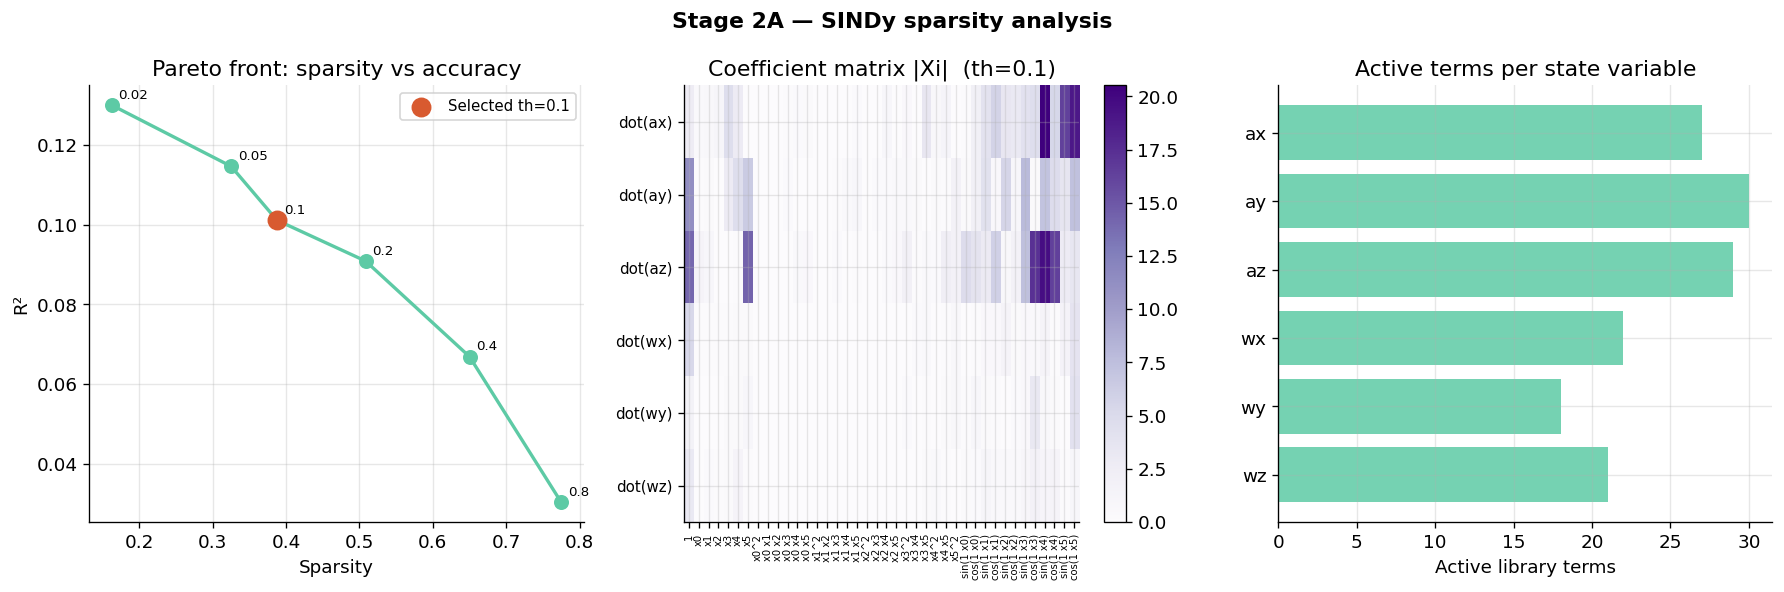

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ths  = list(sindy_sweep.keys())
r2s  = [sindy_sweep[t]['r2']       for t in ths]
sprs = [sindy_sweep[t]['sparsity'] for t in ths]
axes[0].plot(sprs, r2s, 'o-', color=C['dev0'], ms=8, lw=2)
for th,s,r in zip(ths,sprs,r2s):
    axes[0].annotate(f'{th}', (s,r), xytext=(4,4), textcoords='offset points', fontsize=8)
axes[0].scatter([sindy_sweep[BEST_TH]['sparsity']], [sindy_sweep[BEST_TH]['r2']],
                color='#D85A30', s=120, zorder=5, label=f'Selected th={BEST_TH}')
axes[0].set_xlabel('Sparsity')
axes[0].set_ylabel('R²')
axes[0].set_title('Pareto front: sparsity vs accuracy')
axes[0].legend(fontsize=9)

coef       = best_model.coefficients()
feat_names = best_model.get_feature_names()
im = axes[1].imshow(np.abs(coef), aspect='auto', cmap='Purples', interpolation='nearest')
axes[1].set_xticks(range(len(feat_names)))
axes[1].set_xticklabels(feat_names, rotation=90, fontsize=6)
axes[1].set_yticks(range(len(state_names)))
axes[1].set_yticklabels([f'dot({s})' for s in state_names], fontsize=9)
axes[1].set_title(f'Coefficient matrix |Xi|  (th={BEST_TH})')
plt.colorbar(im, ax=axes[1])

axes[2].barh(state_names, (coef!=0).sum(axis=1), color=C['dev0'], alpha=0.85)
axes[2].set_xlabel('Active library terms')
axes[2].set_title('Active terms per state variable')
axes[2].invert_yaxis()

plt.suptitle('Stage 2A — SINDy sparsity analysis', fontweight='bold')
plt.tight_layout()
plt.show()

### 2A.2 — Derivative Reconstruction & Cross-Device Generalisation

In [59]:
print('=== DISCOVERED EQUATIONS ===')
best_model.print()
r2_d0 = best_model.score(X0, t=t0)
r2_d1 = best_model.score(X1, t=t1)
print(f'\nR² Device 0 (train):  {r2_d0:.4f}')
print(f'R² Device 1 (unseen): {r2_d1:.4f}')

=== DISCOVERED EQUATIONS ===
(x0)' = -2.640 1 + -0.425 x0 +  0.763 x1 + -1.043 x2 +  4.595 x3 + -2.778 x4 +  0.196 x0 x3 +  0.272 x0 x4 +  0.331 x0 x5 +  0.309 x1 x5 + -0.905 x2 x4 +  0.613 x3^2 +  3.429 x3 x5 + -0.716 x4^2 + -1.241 x4 x5 + -0.239 sin(1 x0) + -2.019 cos(1 x0) + -4.069 sin(1 x1) + -5.747 cos(1 x1) +  3.372 sin(1 x2) + -3.081 cos(1 x2) +  4.161 sin(1 x3) + -4.613 cos(1 x3) + -20.517 sin(1 x4) +  5.381 cos(1 x4) +  16.289 sin(1 x5) + -18.897 cos(1 x5)
(x1)' = -11.299 1 + -0.232 x0 +  0.385 x1 + -2.726 x3 +  4.603 x4 +  6.425 x5 + -0.244 x0 x3 +  0.216 x1 x3 +  0.480 x1 x4 +  0.854 x1 x5 +  0.252 x2 x3 +  0.310 x2 x4 + -0.409 x2 x5 +  0.531 x3^2 + -0.381 x3 x4 + -0.399 x4^2 + -0.179 x4 x5 +  1.721 x5^2 +  0.364 sin(1 x0) +  2.077 cos(1 x0) +  4.176 sin(1 x1) + -0.632 cos(1 x1) +  5.595 sin(1 x2) + -0.855 cos(1 x2) +  7.794 sin(1 x3) +  0.375 cos(1 x3) +  7.164 sin(1 x4) +  4.764 cos(1 x4) + -3.680 sin(1 x5) +  7.315 cos(1 x5)
(x2)' = -14.030 1 +  1.331 x0 +  0.877 x1 + -0.

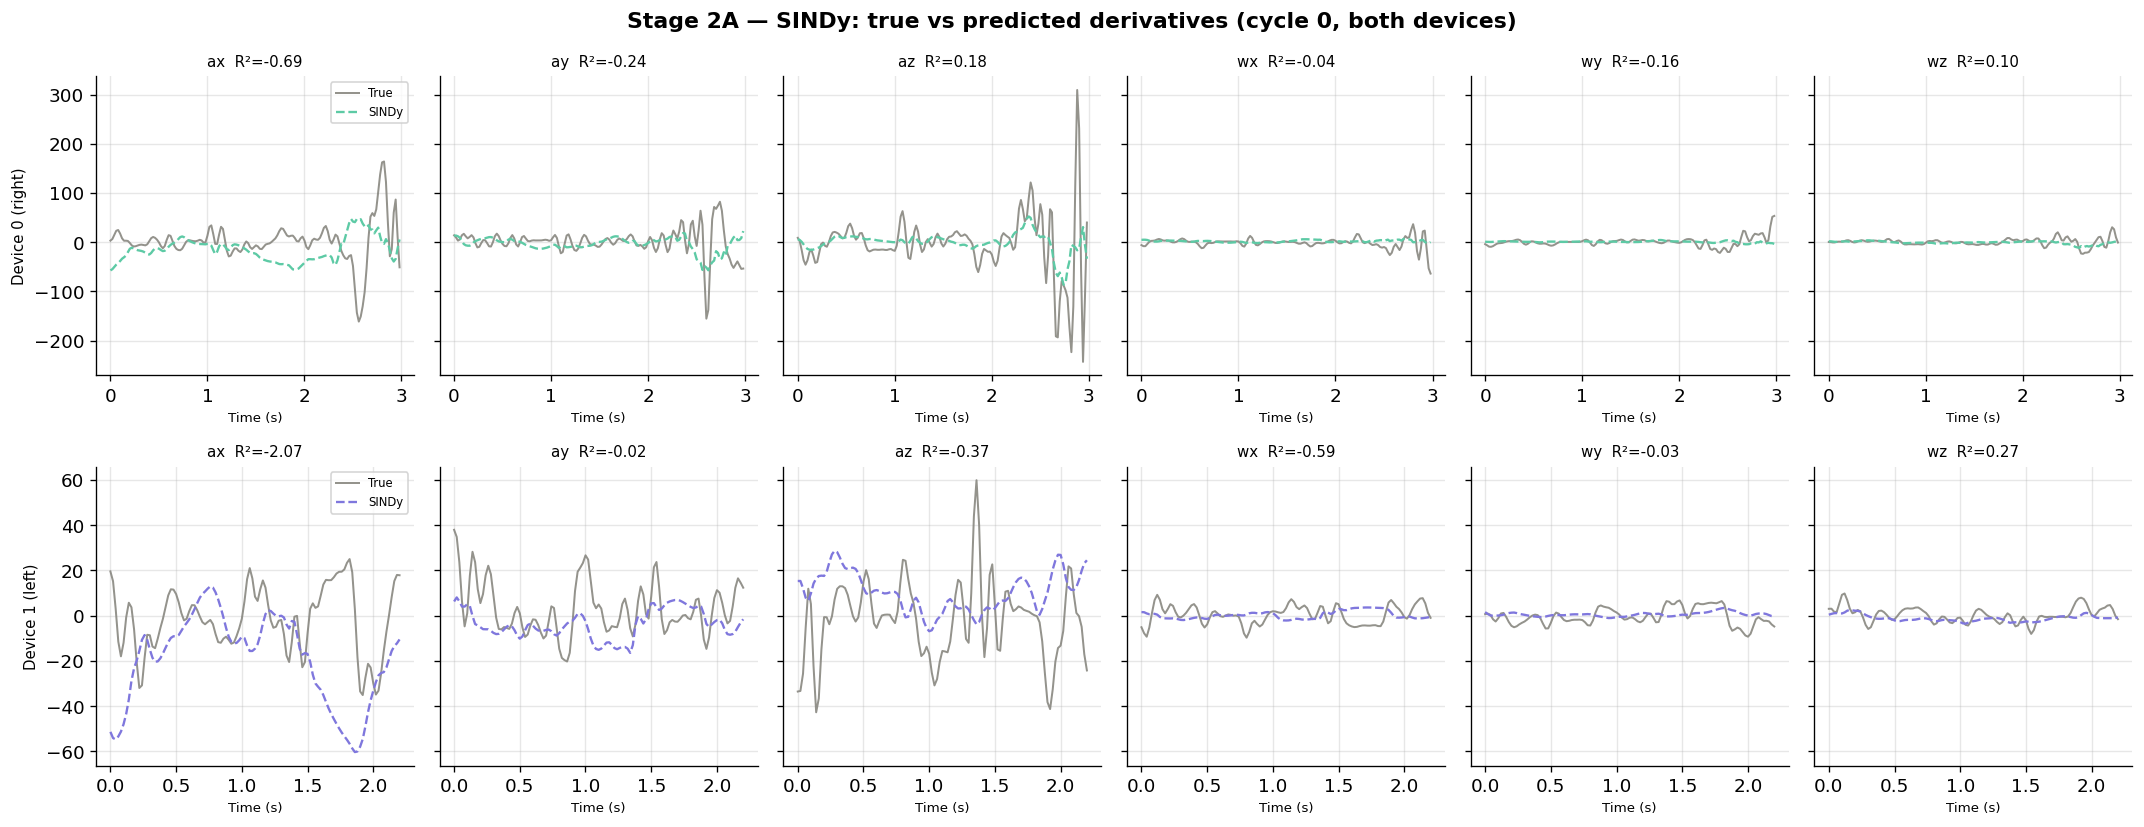

In [60]:
# Derivative reconstruction — both devices, cycle 0
fig, axes = plt.subplots(2, 6, figsize=(18, 7), sharey='row')
for dev_idx, (X, t, cycles, label, col) in enumerate([
    (X0, t0, cycles0, 'Device 0 (right)', C['dev0']),
    (X1, t1, cycles1, 'Device 1 (left)',  C['dev1']),
]):
    s, e    = cycles[0]
    X_cyc   = X[s:e]
    t_cyc   = t[s:e]
    dX_true = np.gradient(X_cyc, t_cyc, axis=0)
    dX_pred = best_model.predict(X_cyc)
    for i, name in enumerate(state_names):
        ax = axes[dev_idx, i]
        ax.plot(t_cyc, dX_true[:,i], color=C['gray'], lw=1.2, alpha=0.9, label='True')
        ax.plot(t_cyc, dX_pred[:,i], color=col,       lw=1.4, ls='--',   label='SINDy')
        r2 = 1 - np.var(dX_true[:,i]-dX_pred[:,i]) / (np.var(dX_true[:,i])+1e-10)
        ax.set_title(f'{name}  R²={r2:.2f}', fontsize=9)
        ax.set_xlabel('Time (s)', fontsize=8)
        if i == 0:
            ax.set_ylabel(label, fontsize=9)
            ax.legend(fontsize=7)
plt.suptitle('Stage 2A — SINDy: true vs predicted derivatives (cycle 0, both devices)',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2B — PINN: Trajectory Reconstruction as an Inverse Problem

One PINN corrector is trained per device per cycle. The composite loss is:
$$\mathcal{L} = \underbrace{\|\ddot{\mathbf{p}} - \hat{\mathbf{a}}\|^2}_{\mathcal{L}_{\text{data}}} + \lambda \underbrace{(\mathcal{L}_{\text{boundary}} + \mathcal{L}_{\text{periodic}} + \mathcal{L}_{\text{jerk}})}_{\mathcal{L}_{\text{physics}}}$$

**Validation**: Periodicity residual $\|\mathbf{p}(T)-\mathbf{p}(0)\|$ — self-supervised, no ground truth needed.

### 2B.1 — Naive Double Integration (Baseline, both devices)

In [61]:
def naive_integrate(t, A, s, e):
    tc, Ac = t[s:e], A[s:e]
    v = np.column_stack([
        integrate.cumulative_trapezoid(Ac[:,d], tc, initial=0) for d in range(3)
    ])
    p = np.column_stack([
        integrate.cumulative_trapezoid(v[:,d],  tc, initial=0) for d in range(3)
    ])
    return tc, v, p

naive0, naive1 = [], []
for (s0,e0),(s1,e1) in zip(cycles0, cycles1):
    tc0,vc0,pc0 = naive_integrate(t0, A0, s0, e0)
    tc1,vc1,pc1 = naive_integrate(t1, A1, s1, e1)
    naive0.append({'t':tc0,'v':vc0,'p':pc0,'s':s0,'e':e0})
    naive1.append({'t':tc1,'v':vc1,'p':pc1,'s':s1,'e':e1})

drift0 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in naive0]
drift1 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in naive1]
print('Naive drift |p(T)-p(0)|:')
for k in range(n_cycles):
    print(f'  Cycle {k}:  D0={drift0[k]:.4f}m   D1={drift1[k]:.4f}m')
print(f'  Mean   D0={np.mean(drift0):.4f}m   D1={np.mean(drift1):.4f}m  <- baseline')

Naive drift |p(T)-p(0)|:
  Cycle 0:  D0=20.2908m   D1=7.3056m
  Cycle 1:  D0=0.7651m   D1=3.1997m
  Cycle 2:  D0=1.6415m   D1=1.8101m
  Cycle 3:  D0=3.9114m   D1=1.5197m
  Cycle 4:  D0=3.3598m   D1=5.7120m
  Cycle 5:  D0=1.9351m   D1=7.1522m
  Cycle 6:  D0=7.5679m   D1=3.9333m
  Cycle 7:  D0=7.9598m   D1=9.6426m
  Cycle 8:  D0=5.3158m   D1=7.8976m
  Cycle 9:  D0=3.7103m   D1=5.5206m
  Cycle 10:  D0=5.6777m   D1=4.7207m
  Cycle 11:  D0=4.3832m   D1=2.9528m
  Cycle 12:  D0=5.2026m   D1=8.8927m
  Cycle 13:  D0=10.7235m   D1=4.7878m
  Cycle 14:  D0=12.9477m   D1=6.5093m
  Cycle 15:  D0=2.1888m   D1=6.5199m
  Cycle 16:  D0=3.5348m   D1=8.8342m
  Cycle 17:  D0=0.9515m   D1=8.2963m
  Cycle 18:  D0=3.3579m   D1=10.0500m
  Cycle 19:  D0=2.4102m   D1=4.2933m
  Cycle 20:  D0=3.7787m   D1=1.9431m
  Cycle 21:  D0=3.8227m   D1=5.3251m
  Cycle 22:  D0=2.2618m   D1=3.7007m
  Cycle 23:  D0=5.0645m   D1=6.1119m
  Cycle 24:  D0=5.1357m   D1=8.4465m
  Cycle 25:  D0=2.6621m   D1=7.4498m
  Cycle 26:  D0=2.8

### 2B.2 — PINN Architecture & Loss

In [62]:
class PINNCorrectorNet(nn.Module):
    """
    Input:  [t_norm, sin(2pi*t_norm), cos(2pi*t_norm), ax, ay, az]  (6-dim)
    Output: [dx, dy, dz]  correction added to naive trajectory
    """
    def __init__(self, hidden_dim=64, n_layers=4):
        super().__init__()
        layers = [nn.Linear(6, hidden_dim), nn.Tanh()]
        for _ in range(n_layers-2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 3))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def make_features(tc, Ac):
    T      = tc[-1]-tc[0]
    tn     = (tc-tc[0])/T
    return torch.tensor(np.column_stack([
        tn, np.sin(2*np.pi*tn), np.cos(2*np.pi*tn), Ac
    ]), dtype=torch.float32)


def physics_losses(p, tc, R_arm=0.65):
    dt     = float(np.median(np.diff(tc)))
    L_bnd  = (torch.relu(torch.norm(p, dim=1)-R_arm)**2).mean()
    L_per  = torch.norm(p[-1]-p[0])**2
    jerk   = torch.diff(torch.diff(torch.diff(p,dim=0)/dt,dim=0)/dt,dim=0)/dt
    L_jerk = (jerk**2).sum(dim=1).mean()
    return L_bnd, L_per, L_jerk


def train_pinn_cycle(tc, Ac, p_naive, lam=0.5, epochs=1500, lr=5e-4):
    feats  = make_features(tc, Ac)
    p_base = torch.tensor(p_naive, dtype=torch.float32)
    A_obs  = torch.tensor(Ac,      dtype=torch.float32)
    dt     = float(np.median(np.diff(tc)))
    net    = PINNCorrectorNet()
    opt    = optim.Adam(net.parameters(), lr=lr)
    sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=100, factor=0.5)
    log    = {'total':[],'data':[],'boundary':[],'periodic':[],'jerk':[]}
    for _ in range(epochs):
        opt.zero_grad()
        p      = p_base + net(feats)
        a_pred = torch.diff(torch.diff(p,dim=0)/dt,dim=0)/dt
        L_data = nn.functional.mse_loss(a_pred, A_obs[1:-1])
        L_bnd, L_per, L_jerk = physics_losses(p, tc)
        loss   = L_data + lam*(L_bnd+L_per+0.01*L_jerk)
        loss.backward()
        opt.step()
        sched.step(loss)
        log['total'].append(loss.item())
        log['data'].append(L_data.item())
        log['boundary'].append(L_bnd.item())
        log['periodic'].append(L_per.item())
        log['jerk'].append(L_jerk.item())
    with torch.no_grad():
        p_corr = (p_base+net(feats)).numpy()
    return p_corr, log

print(f'PINN ready. Parameters: {sum(p.numel() for p in PINNCorrectorNet().parameters()):,}')

PINN ready. Parameters: 8,963


### 2B.3 — Lambda Sensitivity (Device 0, cycle 0)

In [63]:
lambdas   = [0.05, 0.1, 0.5, 1.0, 2.0]
lam_sweep = {}
cyc0      = naive0[0]
tc0c, Ac0c, pn0c = cyc0['t'], A0[cyc0['s']:cyc0['e']], cyc0['p']

print('Lambda sweep on cycle 0, Device 0...')
for lam in lambdas:
    p_c, log = train_pinn_cycle(tc0c, Ac0c, pn0c, lam=lam, epochs=800)
    drift    = np.linalg.norm(p_c[-1]-p_c[0])
    lam_sweep[lam] = {'p':p_c,'log':log,'drift':drift}
    print(f'  lam={lam:.2f}  drift={drift:.4f}m  L={log["total"][-1]:.5f}')

LAM = 0.5
print(f'\nSelected lambda={LAM}')

Lambda sweep on cycle 0, Device 0...
  lam=0.05  drift=20.2927m  L=28.27537
  lam=0.10  drift=20.2945m  L=53.55935
  lam=0.50  drift=20.2999m  L=268.61490
  lam=1.00  drift=20.2928m  L=533.62885
  lam=2.00  drift=20.2921m  L=1095.54309

Selected lambda=0.5


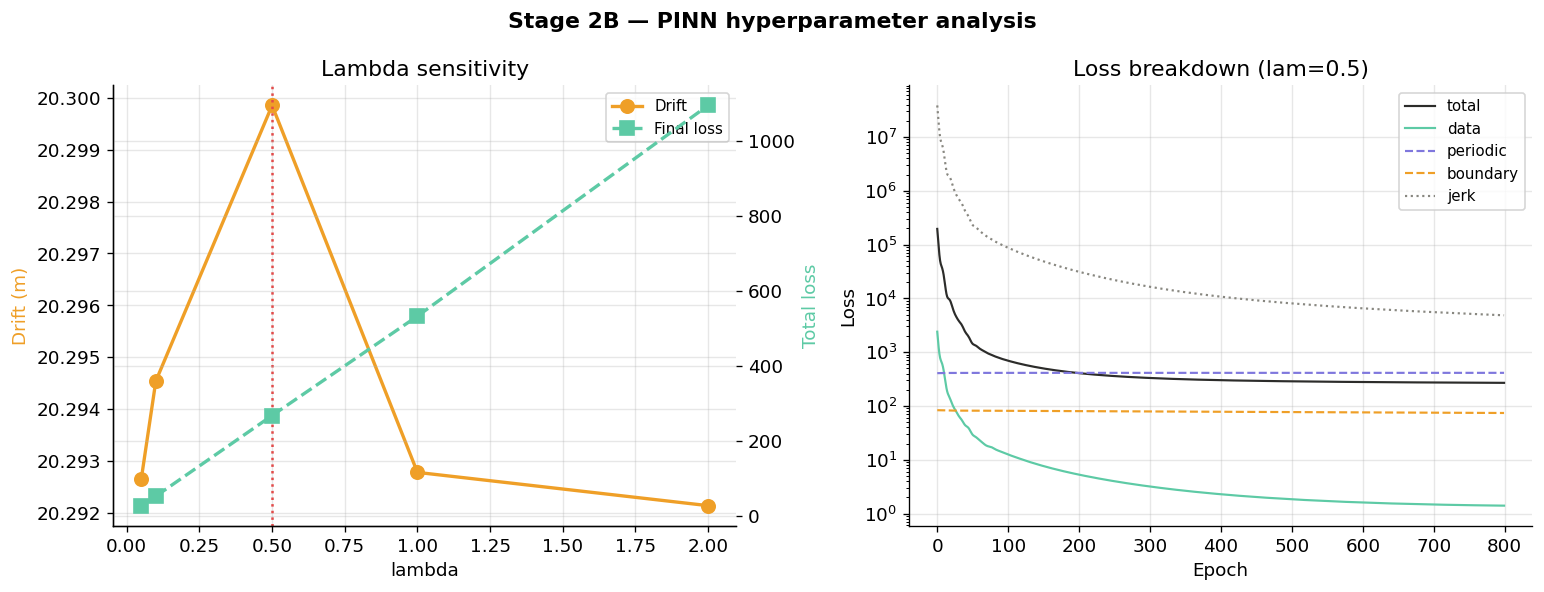

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lams   = list(lam_sweep.keys())
drifts = [lam_sweep[l]['drift']            for l in lams]
losses = [lam_sweep[l]['log']['total'][-1] for l in lams]
ax2    = axes[0].twinx()
l1,  = axes[0].plot(lams, drifts, 'o-', color=C['pinn'], lw=2, ms=8, label='Drift')
l2,  = ax2.plot(lams, losses, 's--', color=C['dev0'],    lw=2, ms=8, label='Final loss')
axes[0].axvline(LAM, color=C['naive'], lw=1.5, ls=':')
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('Drift (m)', color=C['pinn'])
ax2.set_ylabel('Total loss', color=C['dev0'])
axes[0].set_title('Lambda sensitivity')
axes[0].legend(handles=[l1,l2], fontsize=9)
log_sel = lam_sweep[LAM]['log']
for key, col, ls in [('total','#2C2C2A','-'),('data',C['dev0'],'-'),
                      ('periodic',C['dev1'],'--'),('boundary',C['pinn'],'--'),
                      ('jerk',C['gray'],':')]:
    axes[1].plot(log_sel[key], lw=1.3, color=col, ls=ls, label=key)
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title(f'Loss breakdown (lam={LAM})')
axes[1].legend(fontsize=9)
plt.suptitle('Stage 2B — PINN hyperparameter analysis', fontweight='bold')
plt.tight_layout()
plt.show()

### 2B.4 — Full Run: Both Devices, All Cycles

In [65]:
print(f'Training PINN — {n_cycles} cycles x 2 devices (lam={LAM})...\n')
pinn0, pinn1 = [], []

for k in range(n_cycles):
    cyc = naive0[k]
    p_c0, log0 = train_pinn_cycle(cyc['t'], A0[cyc['s']:cyc['e']], cyc['p'], lam=LAM)
    pinn0.append({'p':p_c0,'log':log0,'t':cyc['t'],'s':cyc['s'],'e':cyc['e']})

    cyc = naive1[k]
    p_c1, log1 = train_pinn_cycle(cyc['t'], A1[cyc['s']:cyc['e']], cyc['p'], lam=LAM)
    pinn1.append({'p':p_c1,'log':log1,'t':cyc['t'],'s':cyc['s'],'e':cyc['e']})

    d0p = np.linalg.norm(p_c0[-1]-p_c0[0])
    d1p = np.linalg.norm(p_c1[-1]-p_c1[0])
    print(f'  Cycle {k}:  D0 {drift0[k]:.3f}->{d0p:.3f}m   D1 {drift1[k]:.3f}->{d1p:.3f}m')

pinn_drift0 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in pinn0]
pinn_drift1 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in pinn1]
red0 = 100*(1-np.mean(pinn_drift0)/np.mean(drift0))
red1 = 100*(1-np.mean(pinn_drift1)/np.mean(drift1))
print(f'\nDrift reduction  D0: {red0:.1f}%   D1: {red1:.1f}%')

Training PINN — 42 cycles x 2 devices (lam=0.5)...

  Cycle 0:  D0 20.291->20.285m   D1 7.306->7.306m
  Cycle 1:  D0 0.765->0.727m   D1 3.200->3.224m
  Cycle 2:  D0 1.641->1.623m   D1 1.810->1.813m
  Cycle 3:  D0 3.911->3.900m   D1 1.520->1.542m
  Cycle 4:  D0 3.360->3.361m   D1 5.712->5.674m
  Cycle 5:  D0 1.935->1.876m   D1 7.152->7.146m
  Cycle 6:  D0 7.568->7.548m   D1 3.933->3.925m
  Cycle 7:  D0 7.960->7.960m   D1 9.643->9.640m
  Cycle 8:  D0 5.316->5.413m   D1 7.898->7.907m
  Cycle 9:  D0 3.710->3.704m   D1 5.521->5.583m
  Cycle 10:  D0 5.678->5.710m   D1 4.721->4.732m
  Cycle 11:  D0 4.383->4.415m   D1 2.953->2.984m
  Cycle 12:  D0 5.203->5.186m   D1 8.893->8.906m
  Cycle 13:  D0 10.724->10.743m   D1 4.788->4.763m
  Cycle 14:  D0 12.948->12.959m   D1 6.509->6.506m
  Cycle 15:  D0 2.189->2.199m   D1 6.520->6.517m
  Cycle 16:  D0 3.535->3.436m   D1 8.834->8.833m
  Cycle 17:  D0 0.952->0.890m   D1 8.296->8.347m
  Cycle 18:  D0 3.358->3.304m   D1 10.050->10.059m
  Cycle 19:  D0 2.4

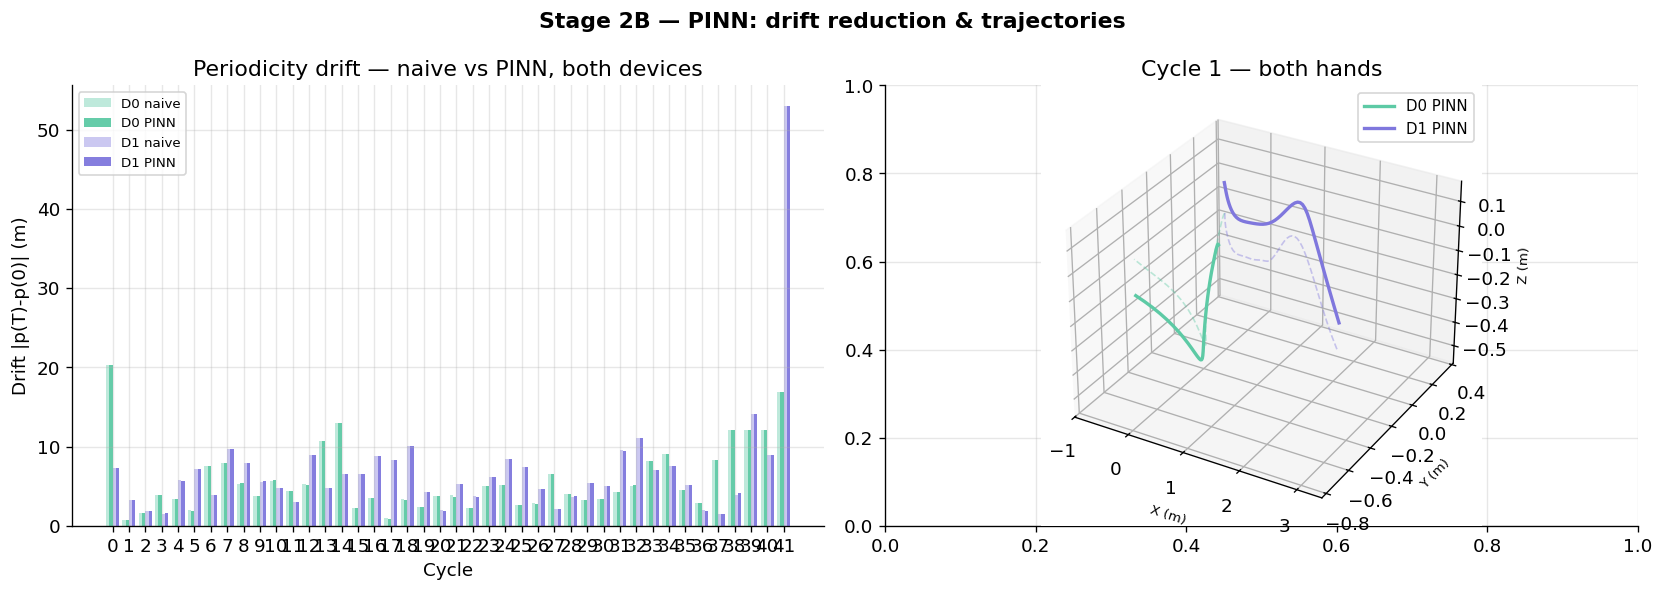

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x, w = np.arange(n_cycles), 0.2
axes[0].bar(x-1.5*w, drift0,      w, color=C['dev0'], alpha=0.4,  label='D0 naive')
axes[0].bar(x-0.5*w, pinn_drift0, w, color=C['dev0'], alpha=0.95, label='D0 PINN')
axes[0].bar(x+0.5*w, drift1,      w, color=C['dev1'], alpha=0.4,  label='D1 naive')
axes[0].bar(x+1.5*w, pinn_drift1, w, color=C['dev1'], alpha=0.95, label='D1 PINN')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Drift |p(T)-p(0)| (m)')
axes[0].set_title('Periodicity drift — naive vs PINN, both devices')
axes[0].legend(fontsize=8)
axes[0].set_xticks(x)

k_show = min(1, n_cycles-1)
ax3d   = fig.add_subplot(122, projection='3d')
for cycs, pinns, col, label in [
    (naive0, pinn0, C['dev0'], 'D0'),
    (naive1, pinn1, C['dev1'], 'D1'),
]:
    pn = cycs[k_show]['p']
    pp = pinns[k_show]['p']
    ax3d.plot(pn[:,0],pn[:,1],pn[:,2], color=col, lw=1, alpha=0.4, ls='--')
    ax3d.plot(pp[:,0],pp[:,1],pp[:,2], color=col, lw=2, label=f'{label} PINN')
ax3d.set_title(f'Cycle {k_show} — both hands')
ax3d.set_xlabel('X (m)', fontsize=8)
ax3d.set_ylabel('Y (m)', fontsize=8)
ax3d.set_zlabel('Z (m)', fontsize=8)
ax3d.legend(fontsize=9)
plt.suptitle('Stage 2B — PINN: drift reduction & trajectories', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2C — DMD + Autoencoder

Both device trajectories are combined into an 18-channel state vector per cycle before DMD and the autoencoder, ensuring the pattern representation captures the full two-hand rope geometry.

### 2C.1 — Dynamic Mode Decomposition (combined two-hand state)

In [67]:
def compute_dmd(X, dt, r=None):
    """
    Exact DMD. X: (n_features, n_timesteps).
    Returns lam_c, Phi, freqs, growth, b, r.
    """
    X1, X2   = X[:,:-1], X[:,1:]
    U, S, Vh = svd(X1, full_matrices=False)
    if r is None:
        r = int(np.searchsorted(np.cumsum(S**2)/np.sum(S**2), 0.99))+1
    U_r, S_r, Vh_r = U[:,:r], S[:r], Vh[:r,:]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ np.diag(1.0/S_r)
    lam_d, W = np.linalg.eig(A_tilde)
    Phi      = X2 @ Vh_r.T @ np.diag(1.0/S_r) @ W
    lam_c    = np.log(lam_d+1e-12) / dt
    freqs    = np.abs(lam_c.imag) / (2*np.pi)
    growth   = lam_c.real
    b        = np.linalg.lstsq(Phi, X[:,0], rcond=None)[0]
    return lam_c, Phi, freqs, growth, b, r


def dmd_reconstruct(Phi, lam_c, b, t):
    T   = t-t[0]
    dyn = np.array([b[k]*np.exp(lam_c[k]*T) for k in range(len(b))])
    return (Phi @ dyn).real


dmd_results = []
for k in range(n_cycles):
    s0,e0 = pinn0[k]['s'], pinn0[k]['e']
    s1,e1 = pinn1[k]['s'], pinn1[k]['e']
    p0, p1 = pinn0[k]['p'], pinn1[k]['p']
    tc      = pinn0[k]['t']
    dt_c    = float(np.median(np.diff(tc)))
    n       = min(p0.shape[0], p1.shape[0], e0-s0, e1-s1)

    state = np.vstack([
        p0[:n].T,  A0[s0:s0+n].T, om0[s0:s0+n].T,
        p1[:n].T,  A1[s1:s1+n].T, om1[s1:s1+n].T,
    ])   # (18, n)

    lam_c, Phi, freqs, growth, b, r = compute_dmd(state, dt_c)
    X_rec   = dmd_reconstruct(Phi, lam_c, b, tc[:n])
    rec_mse = float(np.mean((state-X_rec)**2))
    dmd_results.append({'lam_c':lam_c,'freqs':freqs,'growth':growth,
                        'b':b,'r':r,'X_rec':X_rec,'state':state,
                        'rec_mse':rec_mse,'t':tc[:n]})
    print(f'Cycle {k}: rank={r}  dom_freq={freqs[np.argmax(np.abs(b))]:.3f}Hz  MSE={rec_mse:.6f}')

Cycle 0: rank=6  dom_freq=0.000Hz  MSE=0.806177
Cycle 1: rank=6  dom_freq=1.437Hz  MSE=13.404431
Cycle 2: rank=6  dom_freq=1.512Hz  MSE=9.825822
Cycle 3: rank=6  dom_freq=0.000Hz  MSE=17.431964
Cycle 4: rank=5  dom_freq=1.249Hz  MSE=20.725173
Cycle 5: rank=5  dom_freq=0.721Hz  MSE=1.622892
Cycle 6: rank=6  dom_freq=1.551Hz  MSE=8.284929
Cycle 7: rank=6  dom_freq=0.000Hz  MSE=2529.264542
Cycle 8: rank=4  dom_freq=0.924Hz  MSE=64.275678
Cycle 9: rank=5  dom_freq=0.000Hz  MSE=275.293004
Cycle 10: rank=6  dom_freq=1.763Hz  MSE=36.178855
Cycle 11: rank=7  dom_freq=1.625Hz  MSE=42.103998
Cycle 12: rank=6  dom_freq=0.920Hz  MSE=37.056843
Cycle 13: rank=6  dom_freq=0.000Hz  MSE=21.120647
Cycle 14: rank=5  dom_freq=0.000Hz  MSE=47.767962
Cycle 15: rank=5  dom_freq=0.709Hz  MSE=37.036089
Cycle 16: rank=5  dom_freq=0.868Hz  MSE=20.615663
Cycle 17: rank=5  dom_freq=1.641Hz  MSE=21.293577
Cycle 18: rank=5  dom_freq=0.754Hz  MSE=99.731192
Cycle 19: rank=5  dom_freq=0.000Hz  MSE=46.997356
Cycle 20: r

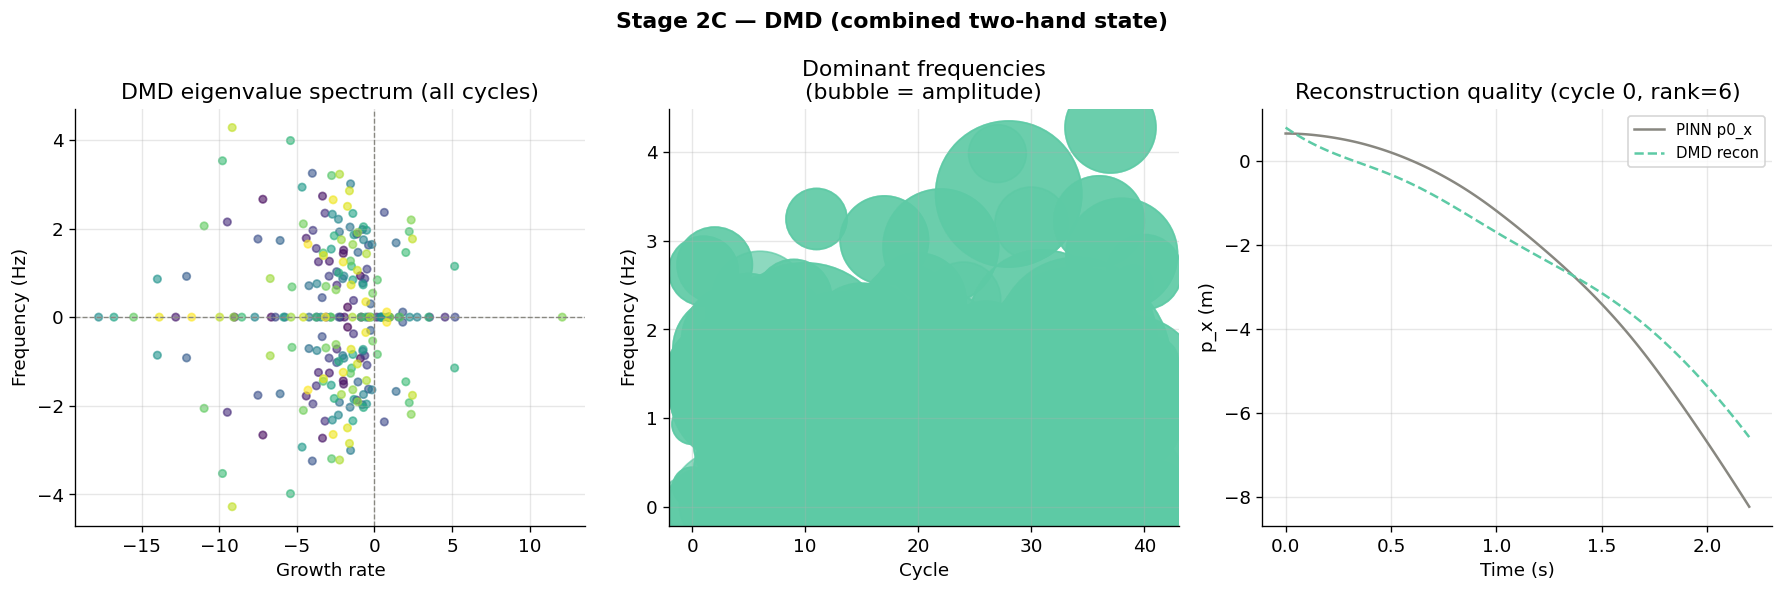

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for k, res in enumerate(dmd_results):
    axes[0].scatter(res['lam_c'].real, res['lam_c'].imag/(2*np.pi),
                    s=20, alpha=0.6, c=[k]*len(res['lam_c']),
                    cmap='viridis', vmin=0, vmax=n_cycles-1)
axes[0].axvline(0, color=C['gray'], lw=0.8, ls='--')
axes[0].axhline(0, color=C['gray'], lw=0.8, ls='--')
axes[0].set_xlabel('Growth rate')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('DMD eigenvalue spectrum (all cycles)')

for k, res in enumerate(dmd_results):
    top = np.argsort(np.abs(res['b']))[::-1][:5]
    axes[1].scatter([k]*len(top), res['freqs'][top],
                    s=np.abs(res['b'][top])*200+10, color=C['dev0'], alpha=0.7)
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title('Dominant frequencies\n(bubble = amplitude)')

res0 = dmd_results[0]
axes[2].plot(res0['t'], res0['state'][0],  color=C['gray'], lw=1.5, label='PINN p0_x')
axes[2].plot(res0['t'], res0['X_rec'][0],  color=C['dev0'], lw=1.5, ls='--', label='DMD recon')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('p_x (m)')
axes[2].set_title(f'Reconstruction quality (cycle 0, rank={res0["r"]})')
axes[2].legend(fontsize=9)
plt.suptitle('Stage 2C — DMD (combined two-hand state)', fontweight='bold')
plt.tight_layout()
plt.show()

### 2C.2 — Autoencoder: Nonlinear Latent Representation

In [69]:
class CycleAutoencoder(nn.Module):
    """
    1D conv autoencoder for two-hand cycle windows.
    Input:  (batch, 18, target_len)  — 9 channels per device
    Latent: (batch, latent_dim)
    """
    def __init__(self, in_ch=18, latent_dim=8):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv1d(in_ch, 32, 7, stride=2, padding=3), nn.Tanh(),
            nn.Conv1d(32,    16, 5, stride=2, padding=2), nn.Tanh(),
            nn.Conv1d(16,     8, 3, stride=2, padding=1), nn.Tanh(),
        )
        self.enc_fc = nn.Linear(8, latent_dim)
        self.dec_fc = nn.Linear(latent_dim, 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(8,  16, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),
            nn.ConvTranspose1d(16, 32, 5, stride=2, padding=2, output_padding=1), nn.Tanh(),
            nn.ConvTranspose1d(32, in_ch, 7, stride=2, padding=3, output_padding=1),
        )
    def encode(self, x):
        return self.enc_fc(self.encoder(x).mean(dim=2))
    def decode(self, z, target_len):
        h   = self.dec_fc(z).unsqueeze(2).expand(-1,-1,target_len//8)
        out = self.decoder(h)
        L   = out.shape[2]
        if L > target_len:   out = out[:,:,:target_len]
        elif L < target_len: out = nn.functional.pad(out, (0, target_len-L))
        return out
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z, x.shape[2]), z


def build_tensors(pinn0, pinn1, A0, A1, om0, om1, target_len=64):
    """(n_cycles, 18, target_len) — both devices, normalised per channel."""
    segs = []
    for k in range(len(pinn0)):
        s0,e0 = pinn0[k]['s'], pinn0[k]['e']
        s1,e1 = pinn1[k]['s'], pinn1[k]['e']
        p0, p1 = pinn0[k]['p'], pinn1[k]['p']
        n = min(p0.shape[0], p1.shape[0], e0-s0, e1-s1)
        state = np.vstack([
            p0[:n].T, A0[s0:s0+n].T, om0[s0:s0+n].T,
            p1[:n].T, A1[s1:s1+n].T, om1[s1:s1+n].T,
        ])
        t_old = np.linspace(0,1,n)
        t_new = np.linspace(0,1,target_len)
        res   = np.array([interp1d(t_old, state[c])(t_new) for c in range(18)])
        mn    = res.mean(axis=1, keepdims=True)
        sd    = res.std(axis=1,  keepdims=True)+1e-8
        segs.append((res-mn)/sd)
    return torch.tensor(np.array(segs), dtype=torch.float32)


TARGET_LEN  = 64
data_tensor = build_tensors(pinn0, pinn1, A0, A1, om0, om1, TARGET_LEN)
print(f'Autoencoder input: {tuple(data_tensor.shape)}  (cycles x channels x time)')

Autoencoder input: (42, 18, 64)  (cycles x channels x time)


In [70]:
AE_EPOCHS = 2000
ae        = CycleAutoencoder(in_ch=18, latent_dim=8)
ae_opt    = optim.Adam(ae.parameters(), lr=1e-3)
ae_losses = []
for epoch in range(AE_EPOCHS):
    ae_opt.zero_grad()
    x_rec, z = ae(data_tensor)
    loss = nn.functional.mse_loss(x_rec, data_tensor)
    loss.backward()
    ae_opt.step()
    ae_losses.append(loss.item())

ae.eval()
with torch.no_grad():
    x_rec_np, latent = ae(data_tensor)
    x_rec_np  = x_rec_np.numpy()
    latent_np = latent.numpy()
print(f'AE trained {AE_EPOCHS} epochs | final loss={ae_losses[-1]:.6f}')

AE trained 2000 epochs | final loss=0.656041


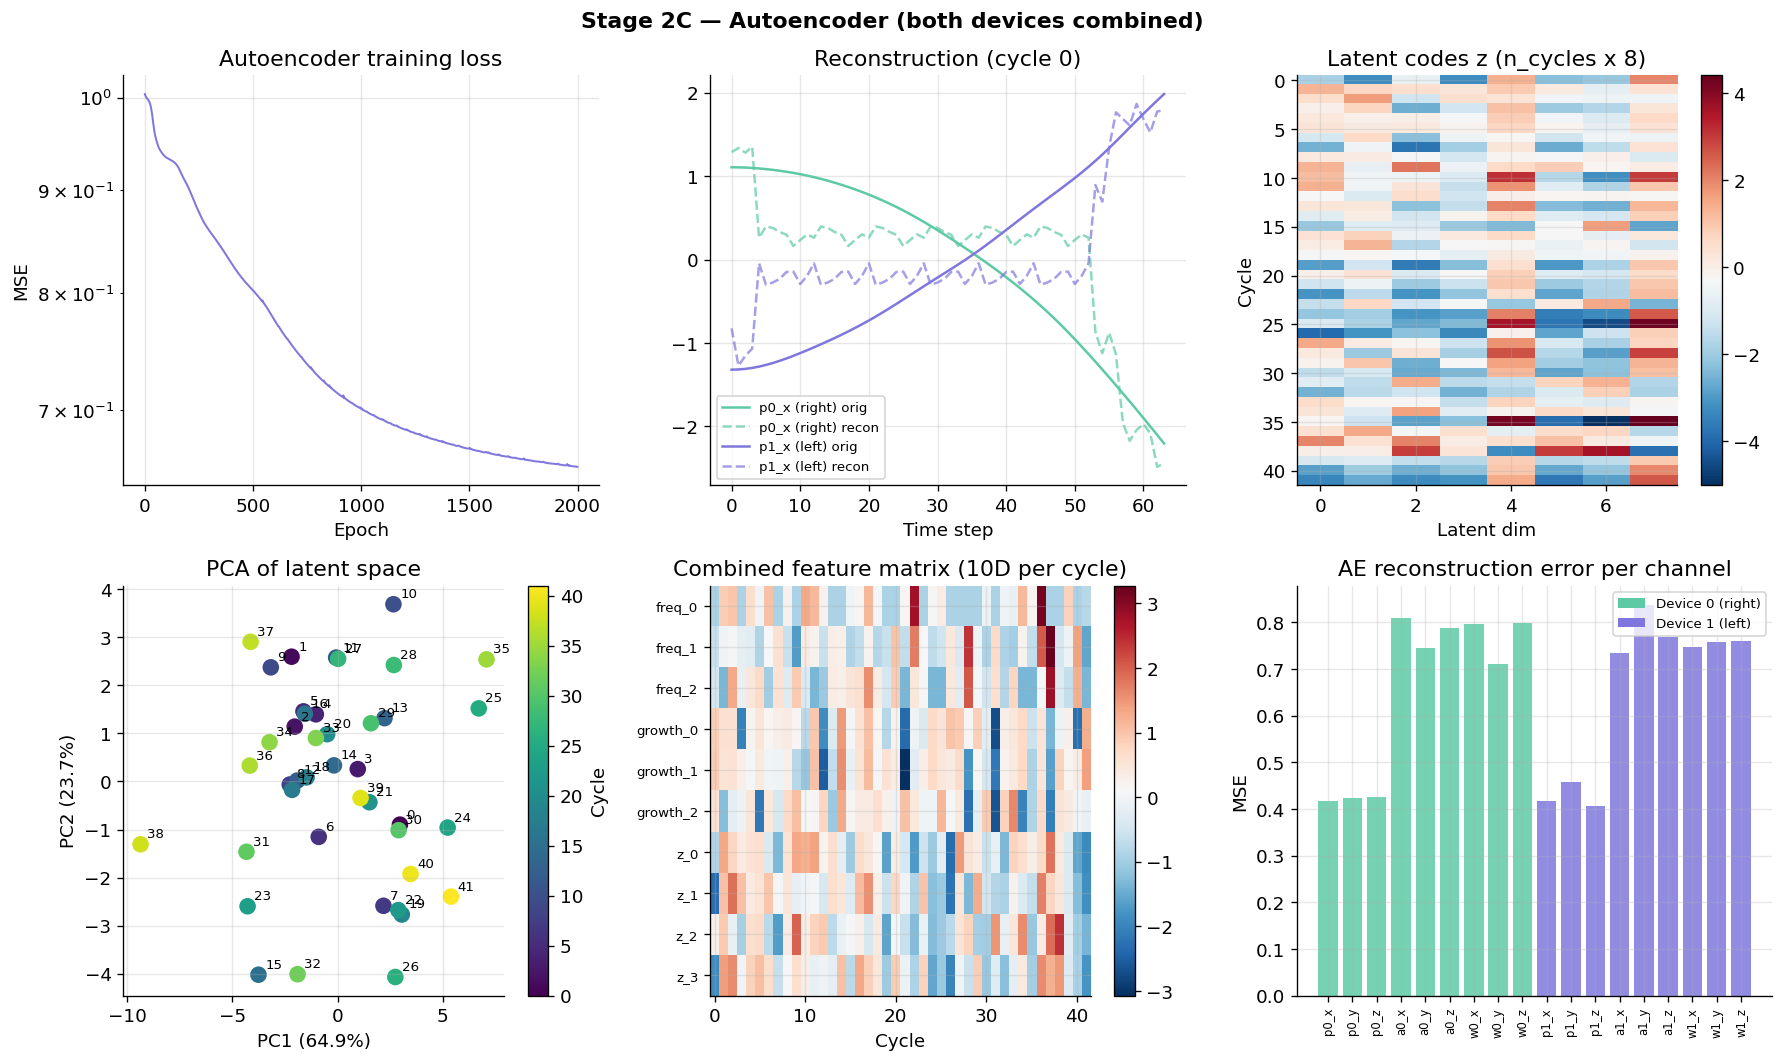

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0,0].plot(ae_losses, color=C['dev1'], lw=1.2)
axes[0,0].set_yscale('log')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('MSE')
axes[0,0].set_title('Autoencoder training loss')

for ch, col, lbl in [(0,C['dev0'],'p0_x (right)'), (9,C['dev1'],'p1_x (left)')]:
    axes[0,1].plot(data_tensor[0,ch].numpy(), color=col, lw=1.5, label=f'{lbl} orig')
    axes[0,1].plot(x_rec_np[0,ch], color=col, lw=1.5, ls='--', alpha=0.7, label=f'{lbl} recon')
axes[0,1].set_xlabel('Time step')
axes[0,1].set_title('Reconstruction (cycle 0)')
axes[0,1].legend(fontsize=8)

im0 = axes[0,2].imshow(latent_np, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[0,2].set_xlabel('Latent dim')
axes[0,2].set_ylabel('Cycle')
axes[0,2].set_title('Latent codes z (n_cycles x 8)')
plt.colorbar(im0, ax=axes[0,2])

pca = PCA(n_components=2)
z2d = pca.fit_transform(latent_np)
sc  = axes[1,0].scatter(z2d[:,0], z2d[:,1], c=range(len(z2d)), cmap='viridis', s=80)
for k,(xx,yy) in enumerate(z2d):
    axes[1,0].annotate(str(k),(xx,yy),xytext=(4,4),textcoords='offset points',fontsize=8)
plt.colorbar(sc, ax=axes[1,0], label='Cycle')
axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1,0].set_title('PCA of latent space')

def extract_features(dmd_res, lat_vec, n_dmd=3):
    top = np.argsort(np.abs(dmd_res['b']))[::-1][:n_dmd]
    return np.concatenate([dmd_res['freqs'][top], dmd_res['growth'][top], lat_vec[:4]])

all_features = np.array([extract_features(dmd_results[k], latent_np[k])
                          for k in range(n_cycles)])
feat_labels  = ([f'freq_{i}' for i in range(3)] +
                [f'growth_{i}' for i in range(3)] +
                [f'z_{i}' for i in range(4)])

im1 = axes[1,1].imshow(StandardScaler().fit_transform(all_features).T,
                        aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[1,1].set_yticks(range(len(feat_labels)))
axes[1,1].set_yticklabels(feat_labels, fontsize=8)
axes[1,1].set_xlabel('Cycle')
axes[1,1].set_title(f'Combined feature matrix ({all_features.shape[1]}D per cycle)')
plt.colorbar(im1, ax=axes[1,1])

chan_names = (['p0_x','p0_y','p0_z','a0_x','a0_y','a0_z','w0_x','w0_y','w0_z'] +
              ['p1_x','p1_y','p1_z','a1_x','a1_y','a1_z','w1_x','w1_y','w1_z'])
ch_err     = np.mean((data_tensor.numpy()-x_rec_np)**2, axis=(0,2))
cols_ch    = [C['dev0']]*9 + [C['dev1']]*9
axes[1,2].bar(range(18), ch_err, color=cols_ch, alpha=0.85)
axes[1,2].set_xticks(range(18))
axes[1,2].set_xticklabels(chan_names, rotation=90, fontsize=7)
axes[1,2].set_ylabel('MSE')
axes[1,2].set_title('AE reconstruction error per channel')
axes[1,2].bar(0,0,color=C['dev0'],label='Device 0 (right)')
axes[1,2].bar(0,0,color=C['dev1'],label='Device 1 (left)')
axes[1,2].legend(fontsize=8)

plt.suptitle('Stage 2C — Autoencoder (both devices combined)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Visualisation — 3D Rope Flow Patterns

Each subplot shows one full cycle. The two coloured curves are the right (plasma) and left (viridis) hand trajectories. Dashed lines connect the hands at cycle start and end, showing the rope's instantaneous position — this is the full geometric pattern fed to the classifier.

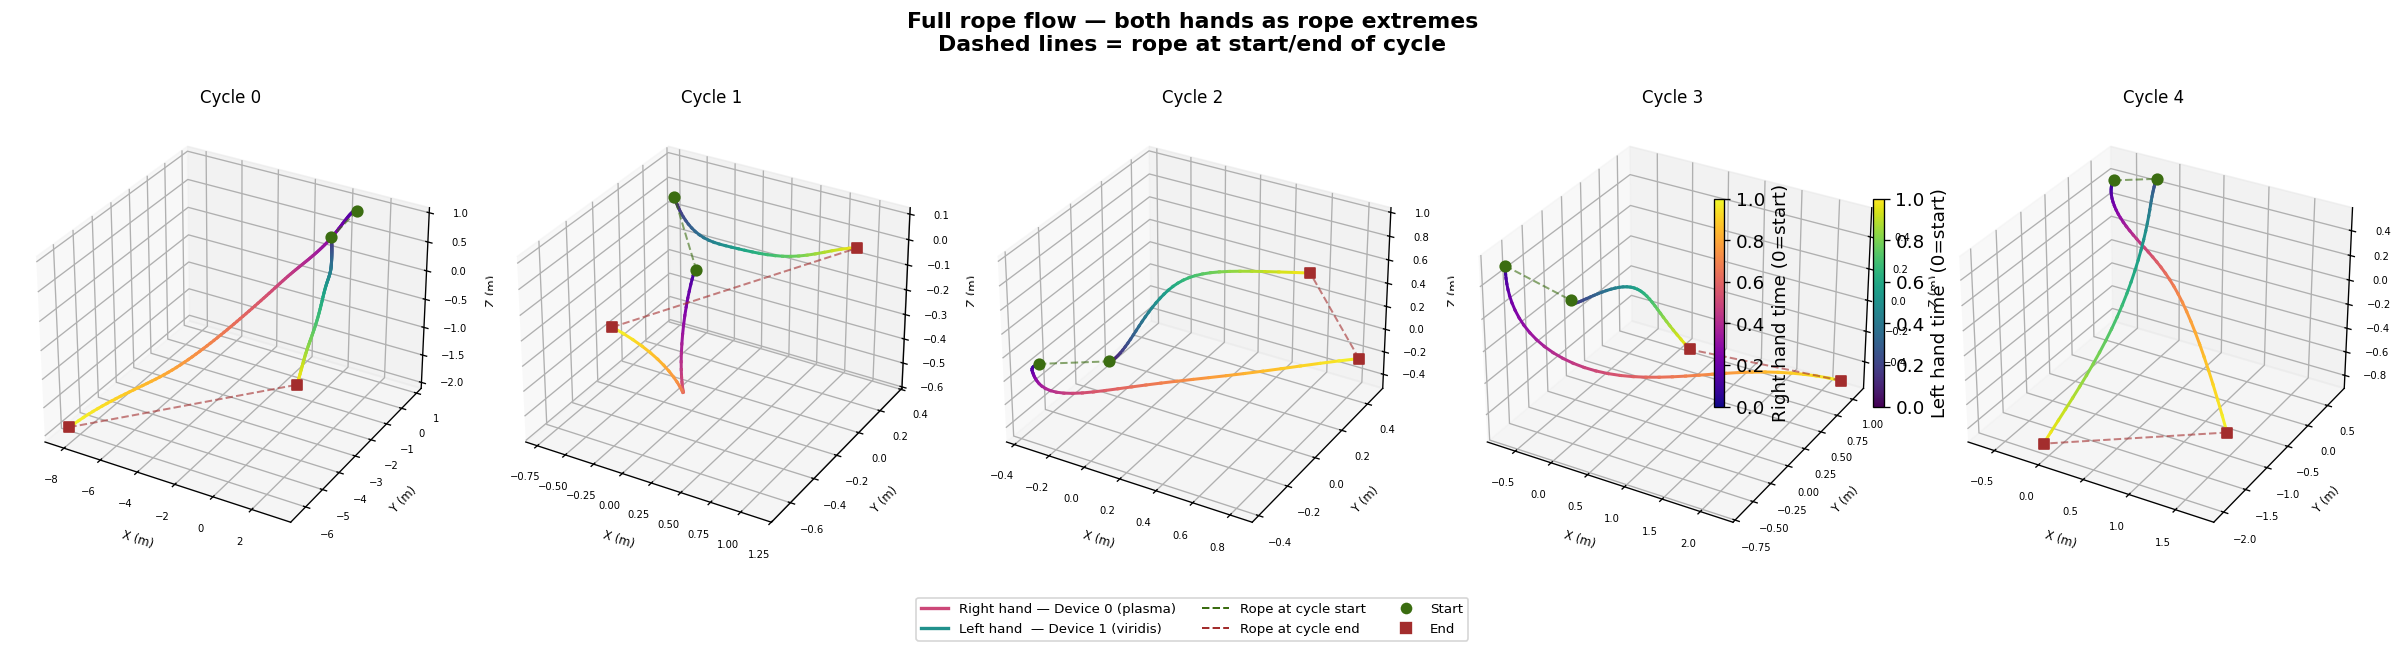

In [72]:
n_cols = min(n_cycles, 5)
fig    = plt.figure(figsize=(4*n_cols, 5))

for col in range(n_cols):
    p0 = pinn0[col]['p']
    p1 = pinn1[col]['p']
    n  = min(len(p0), len(p1))
    p0, p1 = p0[:n], p1[:n]
    t_norm = np.linspace(0, 1, n)

    ax = fig.add_subplot(1, n_cols, col+1, projection='3d')

    # Right hand — plasma
    for i in range(n-1):
        ax.plot(p0[i:i+2,0], p0[i:i+2,1], p0[i:i+2,2],
                color=plt.cm.plasma(t_norm[i]), lw=1.8)
    # Left hand — viridis
    for i in range(n-1):
        ax.plot(p1[i:i+2,0], p1[i:i+2,1], p1[i:i+2,2],
                color=plt.cm.viridis(t_norm[i]), lw=1.8)

    # Start/end markers — both hands
    ax.scatter(*p0[0],  color='#3B6D11', s=40, marker='o', zorder=5)
    ax.scatter(*p1[0],  color='#3B6D11', s=40, marker='o', zorder=5)
    ax.scatter(*p0[-1], color='#A32D2D', s=40, marker='s', zorder=5)
    ax.scatter(*p1[-1], color='#A32D2D', s=40, marker='s', zorder=5)

    # Rope position at start and end
    ax.plot([p0[0,0],p1[0,0]],   [p0[0,1],p1[0,1]],   [p0[0,2],p1[0,2]],
            color='#3B6D11', lw=1.2, ls='--', alpha=0.6)
    ax.plot([p0[-1,0],p1[-1,0]], [p0[-1,1],p1[-1,1]], [p0[-1,2],p1[-1,2]],
            color='#A32D2D', lw=1.2, ls='--', alpha=0.6)

    ax.set_title(f'Cycle {col}', fontsize=10)
    ax.set_xlabel('X (m)', fontsize=7)
    ax.set_ylabel('Y (m)', fontsize=7)
    ax.set_zlabel('Z (m)', fontsize=7)
    ax.tick_params(labelsize=6)

legend_elements = [
    Line2D([0],[0], color=plt.cm.plasma(0.5),  lw=2, label='Right hand — Device 0 (plasma)'),
    Line2D([0],[0], color=plt.cm.viridis(0.5), lw=2, label='Left hand  — Device 1 (viridis)'),
    Line2D([0],[0], color='#3B6D11', lw=1.2, ls='--', label='Rope at cycle start'),
    Line2D([0],[0], color='#A32D2D', lw=1.2, ls='--', label='Rope at cycle end'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3B6D11', ms=8, label='Start'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#A32D2D', ms=8, label='End'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.08))

sm0 = plt.cm.ScalarMappable(cmap='plasma',  norm=plt.Normalize(0,1))
sm1 = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0,1))
fig.colorbar(sm0, ax=fig.axes, shrink=0.45, pad=0.03, label='Right hand time (0=start)')
fig.colorbar(sm1, ax=fig.axes, shrink=0.45, pad=0.08, label='Left hand time  (0=start)')

plt.suptitle('Full rope flow — both hands as rope extremes\n'
             'Dashed lines = rope at start/end of cycle',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

In [73]:
print('=' * 65)
print('PIPELINE SUMMARY')
print('=' * 65)
print(f'\nStage 2A — SINDy')
print(f'  Library:         Polynomial(deg=2) + Fourier(n=1)')
print(f'  Threshold:       {BEST_TH}')
print(f'  R2 D0 (train):   {sindy_sweep[BEST_TH]["r2"]:.4f}')
print(f'  R2 D1 (unseen):  {r2_d1:.4f}')
print(f'  Sparsity:        {sindy_sweep[BEST_TH]["sparsity"]:.1%}')
print(f'\nStage 2B — PINN')
print(f'  lambda:          {LAM}')
print(f'  Drift reduction  D0: {red0:.1f}%   D1: {red1:.1f}%')
print(f'\nStage 2C — DMD + Autoencoder')
print(f'  DMD state dim:   18 (both hands combined)')
print(f'  DMD mean rank:   {np.mean([r["r"] for r in dmd_results]):.1f}')
print(f'  AE latent dim:   {ae.latent_dim}')
print(f'  AE final loss:   {ae_losses[-1]:.6f}')
print(f'  Feature matrix:  {all_features.shape}  -> Stage 3 classifier')
print('=' * 65)
print('\nSuggested ablations:')
print('  - SINDy: polynomial-only vs polynomial + Fourier')
print('  - PINN: drift vs lambda (Pareto curve above)')
print('  - DMD: singular value decay (rank justification)')
print('  - AE: latent dim sweep (4, 8, 16, 32)')

PIPELINE SUMMARY

Stage 2A — SINDy
  Library:         Polynomial(deg=2) + Fourier(n=1)
  Threshold:       0.1
  R2 D0 (train):   0.1011
  R2 D1 (unseen):  -0.1852
  Sparsity:        38.8%

Stage 2B — PINN
  lambda:          0.5
  Drift reduction  D0: 0.2%   D1: 0.0%

Stage 2C — DMD + Autoencoder
  DMD state dim:   18 (both hands combined)
  DMD mean rank:   5.5
  AE latent dim:   8
  AE final loss:   0.656041
  Feature matrix:  (42, 10)  -> Stage 3 classifier

Suggested ablations:
  - SINDy: polynomial-only vs polynomial + Fourier
  - PINN: drift vs lambda (Pareto curve above)
  - DMD: singular value decay (rank justification)
  - AE: latent dim sweep (4, 8, 16, 32)
